This file will  be used to extract images from pickle files and visualize the data we are sending and later usign fro training

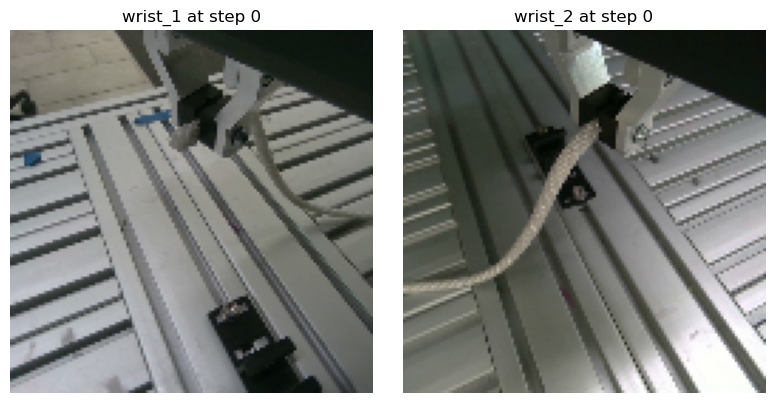

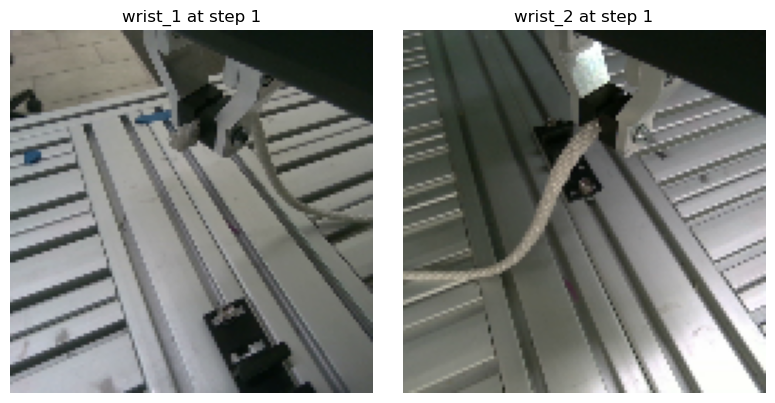

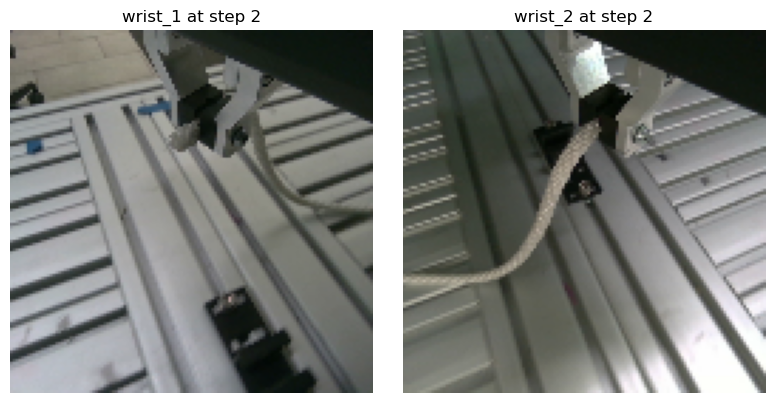

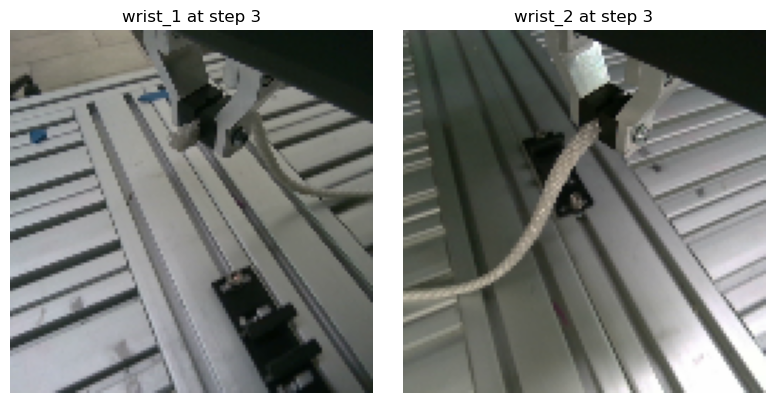

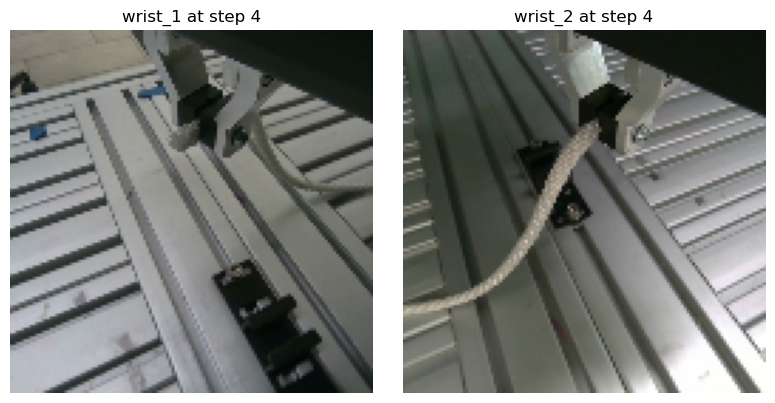

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

file_path = './classifier_demos/negative_cable_route_10_demos_2026-02-12_18-09-24.pkl'
with open(file_path, 'rb') as f:
    data = pickle.load(f)

# Choose which rollout and at which step show
rollout = 0
transition = 5

def prep_image(img: np.ndarray) -> np.ndarray:
    # drop batch dimension if present
    if img.ndim == 4 and img.shape[0] == 1:
        img = img[0]
    # convert channel-first to channel-last if needed
    if img.ndim == 3 and img.shape[0] in (1, 3, 4) and img.shape[-1] not in (1, 3, 4):
        img = np.transpose(img, (1, 2, 0))
    return img

for step in range(rollout, min(rollout + transition, len(data))):
    obs = data[step]["observations"]
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for ax, k in zip(axes, ["wrist_1", "wrist_2"]):
        img = prep_image(np.array(obs[k]))
        ax.imshow(img)
        ax.set_title(f"{k} at step {step}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()